#### HW5 
Plot as a function of x the pressure distribution normalized by the stagnation pressure for the attached nozzle profile. The profile is given in terms of a two column matrix where the first column is the x location and the second column is the radius of an axisymmetric circular nozzle through which the flow goes through. Assume air and CPG. 

1. Case 1: fully subsonic, you may choose a back pressure
2. Case 2: fully subsonic, with the throat at sonic, what is the back pressure?
3. Case 3: Normal shock at x = 0.75 in the nozzle, what is the back pressure?
4. Case 4: Normal shock at the exit of the nozzle, what is the back pressure?
5. Case 5: Ideally expanded, what is the back pressure?
6. What pressure range corresponds to oblique shockwaves at the exit of the nozzle?
7. What pressure range corresponds to expansion waves at the exit of the nozzle

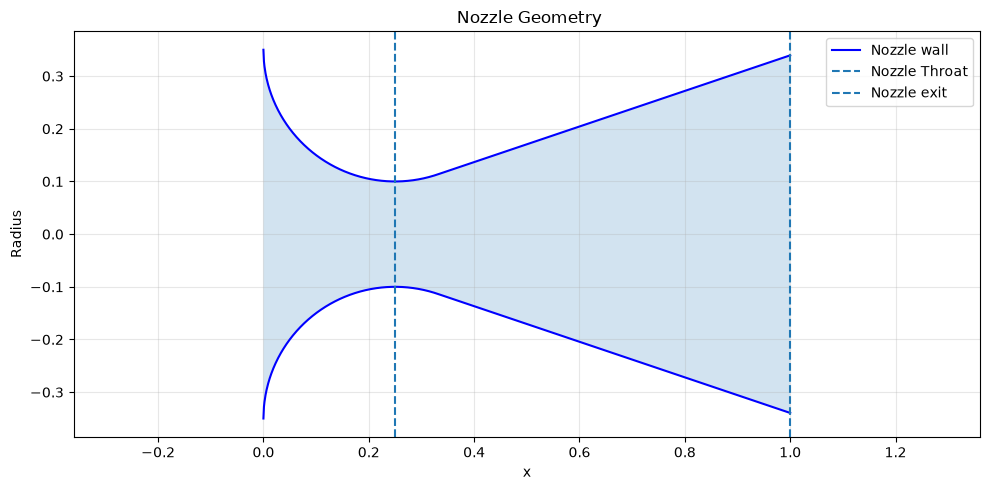

In [63]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import brentq


gamma = 1.4
Nozzle = np.loadtxt("Pnozzle.txt", delimiter=",")
Nozzle_Geom = []

x = Nozzle[:, 0]     
r = Nozzle[:, 1]
A = r * r * np.pi

Nozzle_Geom.append([x, r, A])
A_throat= A[np.argmin(A)]
A_e = A[-1]

plt.figure(figsize=(10, 5))
plt.plot(x, r, color = 'b', label='Nozzle wall')
plt.plot(x, -r, color = 'b' )
plt.fill_between(x, -r, r, alpha = 0.2)
plt.axvline( x=x[A == A_throat], linestyle='--', label='Nozzle Throat')
plt.axvline( x=x[A == A_e], linestyle='--', label='Nozzle exit')
plt.xlabel("x")
plt.ylabel("Radius")
plt.title(" Nozzle Geometry")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW5/area-Mach%20number%20relation.png?raw=true" width="50%">
<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW5/Isentropic%20Flow%20NASA.gif?raw=true" width="50%">


In [ ]:
#MachFromArea function takes in the Area ratio, gamma, type
def MachFromArea (A_ratio, gamma, type):
    
    #This is the 'sub-function' that returns Area ratio subtracted by the given Area ratio to be optimized by Brentq, where solution will be zero.  
    def f (m_i):
        Relation = (1/(m_i ** 2)) * ((2/(gamma +1)) * (1 + ((gamma - 1)/2 * (m_i ** 2)))) ** ((gamma+1)/(gamma-1))
        return Relation - A_ratio ** 2
    
    if type == "subsonic":
        return brentq(f, 0.001, 1)
    else:
        return brentq(f, 1, 10)


# I verified Using the NASA Isentropic Flow calculator : https://www.grc.nasa.gov/www/k-12/airplane/isentrop.html
print(MachFromArea(1.1, 1.4, "subsonic"))   
print(MachFromArea(2.0, 1.4, "supersonic"))  


#The function finds Mach number from the given pressure ratio. It sweeps only from 0.528 to 1, to not account for the supersonic case. 
def MachFromPressure(P_ratio, gamma): 
    def f(m_i): 
        M = m_i ** 2 
        Relation = (1 + ((gamma-1)/2)*M) **((-gamma)/(gamma-1))
        return Relation - P_ratio
    return brentq(f,0, 100)


def PressureRatio(A_ratio, gamma, type): 
    m = MachFromArea(A_ratio, gamma, type)
    M = m * m
    P_ratio = (1 + ((gamma -1)/2) * M) ** (-gamma / (gamma - 1))
    return P_ratio

def AreaRatio(m_i, gamma): 
    M = m_i ** 2 
    A_ratio = np.sqrt(1/M * ((2/(gamma+1))*(1 + ((gamma-1)/2) * M)) ** ((gamma+1)/(gamma-1)))
    return A_ratio


0.6923991394638542
2.1971981216521863


#### Part A
Fully subsonic case, with arbitary back pressure. I chose 99.9% of critical back pressure

1. Calculate the imaginary area Astar where M=1 as a ratio to A_e 
2. Calculate the Mach number of A_given / Imaginary A_star
3. Calculate the normalized pressure ratio based on the area ratio found in step 2.
4. Plot the results

Area Ratio of Imaginary Nozzle Astar 15.319269778894412
Exit Mach number: 0.03780860346801294
Critical area A*: 0.023629287097654297
Back pressure ratio: 0.999


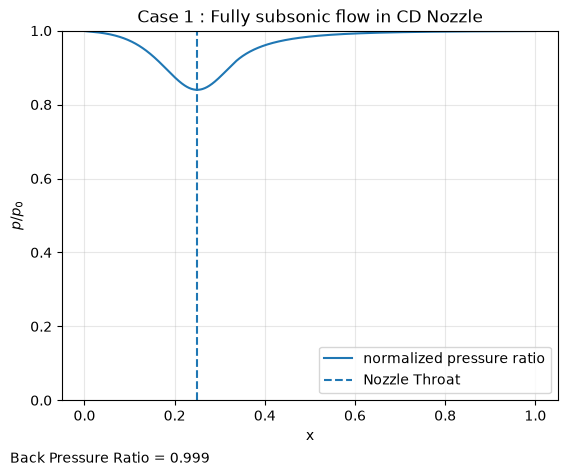

In [142]:
gamma = 1.4
Pb_ratio = 0.999

# Subsonic Mach number at the nozzle exit
M_exit = MachFromPressure(Pb_ratio, gamma)

# Exit area / critical area
A_ratio_e = AreaRatio(M_exit, gamma)

# Estimate critical area
Astar = A[-1] / A_ratio_e
print("Area Ratio of Imaginary Nozzle Astar", A_ratio_e)
print("Exit Mach number:", M_exit)
print("Critical area A*:", Astar)

p_x = np.array([PressureRatio(Ai / Astar, gamma, "subsonic") for Ai in A])

print(f"Back pressure ratio:", Pb_ratio)

plt.plot(x, p_x, label=f"normalized pressure ratio")
plt.axvline( x=x[A == A_throat], linestyle='--', label='Nozzle Throat')
plt.xlabel("x")
plt.ylabel("$p/p_0$")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.legend(loc = 'lower right')
plt.figtext(0.2, -0.02,"Back Pressure Ratio = 0.999",ha="center",fontsize=10)
plt.title("Case 1 : Fully subsonic flow in CD Nozzle")
plt.show()

#### PART B
Fully subsonic, with the throat at sonic, what is the back pressure?

1. For the full subsonic flow with only the throat at sonic, A_throat = A_star. 
2. Calculate the mach number of A_given / A_star area ratio. 
3. Calculate the normalized pressure ratio based on the area ratio found in step 2. 
4. Plot the results. 

Back pressure ratio:


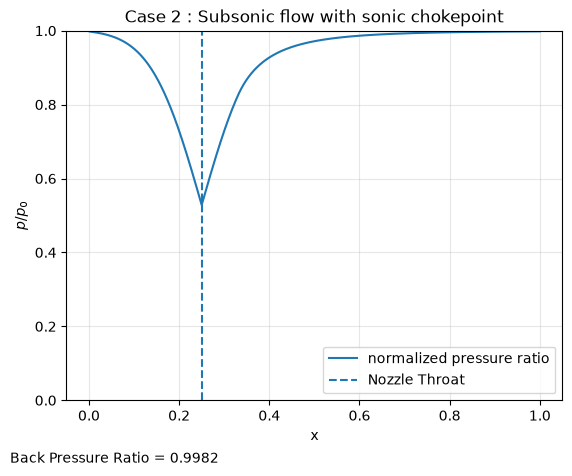

In [145]:
Nozzle_ratio = A_e/A_throat 

p_x = np.array([PressureRatio(Ai / A_throat, gamma, "subsonic") for Ai in A])

print(f"Back pressure ratio:", )

plt.plot(x, p_x, label=f"normalized pressure ratio")
plt.axvline( x=x[A == A_throat], linestyle='--', label='Nozzle Throat')
plt.xlabel("x")
plt.ylabel("$p/p_0$")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.title("Case 2 : Subsonic flow with sonic chokepoint")
plt.figtext(0.2, -0.02,f"Back Pressure Ratio = {p_x[-1]:.4f}",ha="center",fontsize=10)
plt.legend()
plt.show()

#### PART C

Case 3: Normal shock at x = 0.75 in the nozzle, what is the back pressure? <br>
<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW5/normal%20shock%20relations.jpg?raw=true" width="50%">

<br>

1. Up until x = 0.75, the normalized pressure looks exactly like Case 5, ideally expanded. 
2. At x = 0.75, using the A(x=0.75), find the Mach number. 
3. Construct the imaginary A_star2 like case 1
3. Using the found mach number, go through the normal shock to find the M2 after the NS and the pressure ratio after the Normal Shock 
4. $$\frac{p_e}{p_{01}} = \left(\frac{p_e}{p_{02}}\right)\left(\frac{p_{02}}{p_{01}}\right)$$

In [191]:
# This function calculates the mach after the normal shock using the Normal Shock relations
def NSMach(m_1, gamma): 
    M = m_1 ** 2 
    Mach = ((gamma -1) * M + 2)/(2 * gamma * M - (gamma - 1))
    return np.sqrt(Mach)

#This function calculates the pressure ratio P2/P1 after the normal shock using the Normal Shock relations
def NSPressure(m_1, gamma): 
    M = m_1 **2 
    return (2* gamma * M - (gamma -1)) / (gamma + 1)

#This function calculates the stag pressure ratio
def NSStagPressure(m_1, gamma): 
    M = m_1 ** 2
    relation = ((((gamma + 1) * M)/((gamma -1)*M + 2)) ** (gamma/(gamma -1))) * ((gamma +1)/((2*gamma*M)-(gamma-1))) ** (1/(gamma-1))
    return relation

print(NSMach(2, 1.4))
print(NSPressure(2,1.4))
print(NSStagPressure(2, 1.4))


0.5773502691896257
4.5
0.7208738614847455


0.2042899541409645


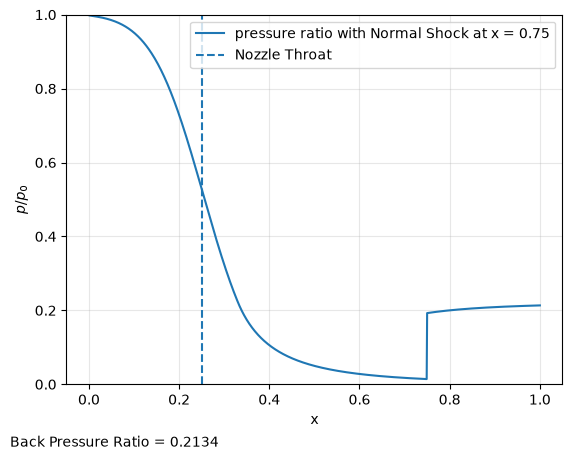

In [192]:
i_throat = np.argmin(A)
i_shock = np.searchsorted(x, 0.75)

p_x = np.zeros(len(A))
gamma = 1.4

m_1 = MachFromArea(((A[i_shock])/A[i_throat]), gamma, 'supersonic')
m_2 = NSMach(m_1, gamma)
A_star2 = A[i_shock] / AreaRatio(m_2, gamma)
StagPressure = NSStagPressure(m_1, gamma)

for i in range (0, len(A)): 
    if i < i_throat : 
        p_x[i] = PressureRatio((A[i]/A[i_throat]), gamma, 'subsonic')
    elif i<i_shock:
        p_x[i] = PressureRatio((A[i]/A[i_throat]), gamma, 'supersonic')
    elif i>=i_shock: 
        p_x[i] = (StagPressure * PressureRatio((A[i]/A_star2), gamma, 'subsonic'))

        #Need to find the imaginary throat after the NS, A_star2

#Printing Mach number right before the NS
#Printing Area right before the NS 
print(A[i_shock])


plt.plot(x, p_x, label=f"pressure ratio with Normal Shock at x = 0.75")
plt.xlabel("x")
plt.ylabel("$p/p_0$")
plt.axvline( x=x[A == A_throat], linestyle='--', label='Nozzle Throat')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.legend()
plt.figtext(0.2, -0.02,f"Back Pressure Ratio = {p_x[-1]:.4f}",ha="center",fontsize=10)
plt.show()

#### PART D 
Case 4 : Normal Shock at the nozzle exit. What is the back pressure? 

0.3619834237319151


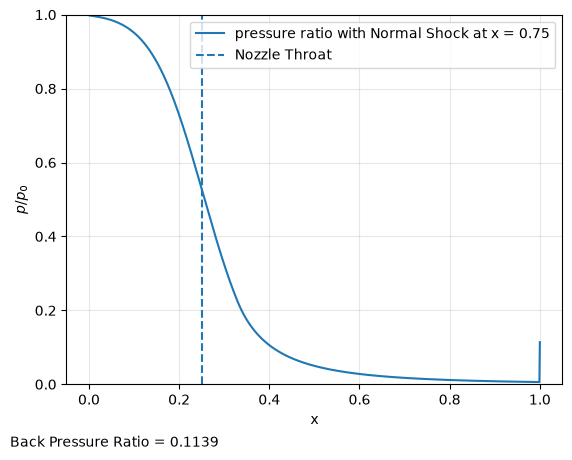

In [ ]:
i_throat = np.argmin(A)
i_shock = np.searchsorted(x, 1)

p_x = np.zeros(len(A))
gamma = 1.4

m_1 = MachFromArea(((A[i_shock])/A[i_throat]), gamma, 'supersonic')
m_2 = NSMach(m_1, gamma)
A_star2 = A[i_shock] / AreaRatio(m_2, gamma)
StagPressure = NSStagPressure(m_1, gamma)

for i in range (0, len(A)): 
    if i < i_throat : 
        p_x[i] = PressureRatio((A[i]/A[i_throat]), gamma, 'subsonic')
    elif i<i_shock:
        p_x[i] = PressureRatio((A[i]/A[i_throat]), gamma, 'supersonic')
    elif i>=i_shock: 
        p_x[i] = (StagPressure * PressureRatio((A[i]/A_star2), gamma, 'subsonic'))

        #Need to find the imaginary throat after the NS, A_star2

#Printing Mach number right before the NS
#Printing Area right before the NS 
print(A[i_shock])


plt.plot(x, p_x, label=f"pressure ratio with Normal Shock at Nozzle End")
plt.xlabel("x")
plt.ylabel("$p/p_0$")
plt.axvline( x=x[A == A_throat], linestyle='--', label='Nozzle Throat')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.legend()
plt.figtext(0.2, -0.02,f"Back Pressure Ratio = {p_x[-1]:.4f}",ha="center",fontsize=10)
plt.show()

#### PART E
Case 5 : Ideally Expanded. What is the back pressure?

0.005912985826544639


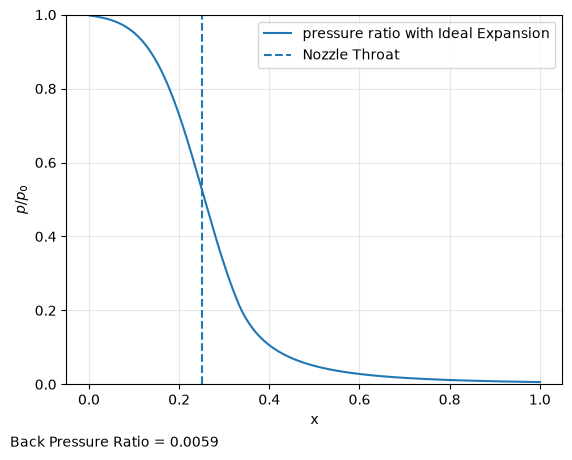

In [146]:
Nozzle_ratio = A_e/A_throat
x_throat = np.argmin(A)

p_x = np.zeros(len(A))
for i in range (0, len(A)): 
    if i < x_throat : 
        p_x[i] = PressureRatio((A[i]/A[x_throat]), gamma, 'subsonic')
    else : 
        p_x[i] = PressureRatio((A[i]/A[x_throat]), gamma, 'supersonic')

print(p_x[-1])

plt.plot(x, p_x, label=f"pressure ratio with Ideal Expansion")
plt.xlabel("x")
plt.ylabel("$p/p_0$")
plt.axvline( x=x[A == A_throat], linestyle='--', label='Nozzle Throat')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.legend()
plt.figtext(0.2, -0.02,f"Back Pressure Ratio = {p_x[-1]:.4f}",ha="center",fontsize=10)
plt.show()

#### Part F 
What pressure range corresponds to oblique shockwaves at the exit of the nozzle? 

The Pressure difference between the Exit pressure in the Part D, Normal shock at the end of the nozzle, to the exit pressure of the ideally expanded nozzle corresponds to oblique shockwaves at the exit of the nozzle. Thus, 

$$0.0059 \le \frac{P_b}{P_0} \le 0.1139$$

corresponds to the expansion wave.

#### Part G 
What pressure range corresponds to expansion waves at the exit of the nozzle

The pressure range from 0 to the back pressure ratio of the ideally expanded nozzle corresponds to the expansion wave regime. Thus, the back pressure ratio range

$$0 \le \frac{P_b}{P_0} \le 0.0059$$

corresponds to the expansion wave.